# Notebook 11 — Hierarchical bootstrap

*SWC ENC 2026 · behaviour module · Part 2 (population-level inference)*

The last of the inference notebooks, and the one that takes **nesting** most
seriously. Our data are nested — several sessions per mouse — and sessions from the
same mouse are *not* independent (Notebook 9 showed mouse identity explains most of
the variance). Ignoring that makes error bars too small and p-values too confident.
The **hierarchical bootstrap** fixes it — it's the standard way to get honest error
bars when your measurements come in groups rather than one flat independent sample.

**In this notebook you will:**
1. See why a naive error bar is too small for nested data.
2. Build the **hierarchical bootstrap**.
3. *Prove* it's calibrated by measuring confidence-interval **coverage** against a
   known truth — impossible without synthetic data.

## Setup

One cohort, as in Notebook 9: several sessions per mouse, each summarized by its
recovered **visual − timing** strategy. We'll estimate the cohort's *grand mean*
strategy and ask how uncertain that estimate really is. This cell always runs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import swcbehav as sb

cohort = sb.make_cohort(n_mice=10, sessions_per_mouse=5, seed=3)

def session_strategy(cs):
    X, cols = sb.build_design_matrix(cs.session.table)
    y = cs.session.table["bout_start"].to_numpy().astype(float)
    w = sb.fit_static(X, y)
    return w[1] - w[4]                 # visual weight minus timing weight

strategy = np.array([session_strategy(cs) for cs in cohort])
mouse = np.array([cs.mouse_id for cs in cohort])
by_mouse = [strategy[mouse == m] for m in np.unique(mouse)]
print(f"{len(strategy)} sessions from {len(by_mouse)} mice; grand mean = {strategy.mean():.2f}")

50 sessions from 10 mice; grand mean = -0.47


## 1. Why the naive error bar is wrong

The usual standard error, $s/\sqrt{N}$, assumes $N$ **independent** measurements.
But our 50 sessions aren't 50 independent looks at "a mouse" — they're 5 looks at
each of 10 mice, and sessions from one mouse are alike. Treating all 50 as
independent pretends we have far more information than we do, so the naive standard
error comes out **too small**. You can see the discrepancy by comparing it to the
spread of the *mouse* means (10 genuinely independent units):

In [2]:
naive_sem = strategy.std(ddof=1) / np.sqrt(len(strategy))
mouse_means = np.array([g.mean() for g in by_mouse])
mouse_level_sem = mouse_means.std(ddof=1) / np.sqrt(len(by_mouse))
print(f"naive SEM (all 50 sessions 'independent') : {naive_sem:.3f}")
print(f"mouse-level SEM (10 independent mice)      : {mouse_level_sem:.3f}")
print("the naive SEM is smaller -- it over-counts the evidence")

naive SEM (all 50 sessions 'independent') : 0.743
mouse-level SEM (10 independent mice)      : 1.632
the naive SEM is smaller -- it over-counts the evidence


## 2. The hierarchical bootstrap

The bootstrap estimates uncertainty by **resampling the data with replacement** many
times and watching how much the statistic wobbles. For nested data we resample at
*each level*, mirroring how the data were actually collected:

1. draw a set of mice **with replacement**;
2. within each drawn mouse, draw its sessions **with replacement**;
3. pool and recompute the grand mean.

Repeating this thousands of times gives a distribution for the grand mean whose
width honestly reflects the mouse-level variability. A 95% confidence interval is
just its 2.5th–97.5th percentiles.

**Exercise 1** *(~8 min · meaty)*. Complete `hierarchical_bootstrap`.

> **Check / unstuck.** The hierarchical 95% CI should be **wider** than the naive one
> in the next plot. Stuck? Use `sb.hierarchical_bootstrap(by_mouse)`.

In [3]:
def hierarchical_bootstrap(values_by_group, n_boot=3000, seed=0):
    rng = np.random.default_rng(seed)
    groups = [np.asarray(g, float) for g in values_by_group]
    n_groups = len(groups)
    boot = np.empty(n_boot)
    for b in range(n_boot):
        pooled = []
        for gi in rng.integers(0, n_groups, n_groups):     # resample mice
            g = groups[gi]
            pooled.append(g[rng.integers(0, len(g), len(g))])  # resample sessions
        boot[b] = np.concatenate(pooled).mean()
    return boot

boot = hierarchical_bootstrap(by_mouse)
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"grand mean = {strategy.mean():.2f},  hierarchical 95% CI = [{lo:.2f}, {hi:.2f}]")

grand mean = -0.47,  hierarchical 95% CI = [-3.50, 2.82]


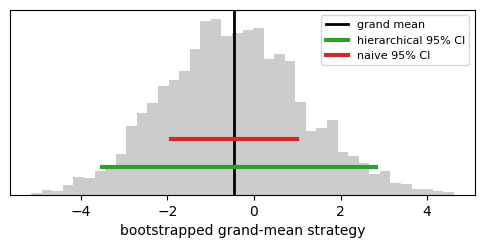

In [4]:
# Compare the two intervals directly.
z_lo, z_hi = strategy.mean() - 1.96 * naive_sem, strategy.mean() + 1.96 * naive_sem
plt.figure(figsize=(6, 2.4))
plt.hist(boot, bins=40, color="0.8")
plt.axvline(strategy.mean(), color="k", lw=2, label="grand mean")
plt.plot([lo, hi], [30, 30], "tab:green", lw=3, label="hierarchical 95% CI")
plt.plot([z_lo, z_hi], [60, 60], "tab:red", lw=3, label="naive 95% CI")
plt.xlabel("bootstrapped grand-mean strategy"); plt.yticks([]); plt.legend(fontsize=8)
plt.show()

The hierarchical interval (green) is **wider** than the naive one (red): once we
respect the nesting, we admit we really only have ~10 independent units, not 50.

## 3. Does it actually work? Coverage

A 95% CI should contain the true value 95% of the time. We can *check* that here,
because we can make data with a **known** grand mean and repeat the experiment many
times. To isolate the statistics we skip the model-fitting and draw the nested
numbers directly: each mouse gets an effect around the true mean, each session
scatters around its mouse. Then we count how often each 95% CI actually covers the
truth. *(The 400 experiments take ~10 s.)*

In [5]:
TRUE_MEAN, BETWEEN_SD, WITHIN_SD = 0.5, 1.0, 1.0
N_MICE, SESS = 10, 5

def draw_nested(rng):
    mouse_eff = rng.normal(TRUE_MEAN, BETWEEN_SD, N_MICE)
    return [rng.normal(mouse_eff[m], WITHIN_SD, SESS) for m in range(N_MICE)]

rng = np.random.default_rng(0)
naive_cover, hier_cover = 0, 0
n_exp = 400
for _ in range(n_exp):
    groups = draw_nested(rng)
    allv = np.concatenate(groups)
    # naive CI: treat all sessions as independent
    sem = allv.std(ddof=1) / np.sqrt(len(allv))
    lo_n, hi_n = allv.mean() - 1.96 * sem, allv.mean() + 1.96 * sem
    naive_cover += lo_n <= TRUE_MEAN <= hi_n
    # hierarchical bootstrap CI
    b = sb.hierarchical_bootstrap(groups, n_boot=500, seed=int(rng.integers(1e9)))
    lo_h, hi_h = np.percentile(b, [2.5, 97.5])
    hier_cover += lo_h <= TRUE_MEAN <= hi_h

print(f"over {n_exp} experiments, the 95% CI contained the truth:")
print(f"  naive CI        : {100 * naive_cover / n_exp:.0f}%   (should be 95%)")
print(f"  hierarchical CI : {100 * hier_cover / n_exp:.0f}%   (should be 95%)")

over 400 experiments, the 95% CI contained the truth:
  naive CI        : 70%   (should be 95%)
  hierarchical CI : 91%   (should be 95%)


The naive interval covers the truth far less than 95% of the time — it's overconfident,
which in practice means false positives. The hierarchical bootstrap lands near 95%,
the coverage it promises. That calibration is why it's the right tool whenever data
come in groups — here, sessions nested within mice.

## Wrap-up — and the end of Part 2

Across the inference notebooks you built the tools for reasoning about a whole
*population*: correlation and linear fits (Notebook 6), variance partitioning and
permutation tests (Notebook 9), multiple-comparison correction (Notebook 10), and
now the hierarchical bootstrap. The recurring lesson is that **structure in the data
— mice, sessions, many tests — has to be built into the inference**, and synthetic
data lets you *prove* a method is calibrated rather than take it on faith. Together
with Part 1's model of the single animal, you now have an end-to-end toolkit for the
behaviour in Piet et al.'s Figures 1–3: from raw licks to a fitted strategy to
population-level statistics.